In [8]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import tensorflow as tf

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten

In [9]:
# Load data
csv_file = glob.glob('/content/*.csv')
data = pd.read_csv(csv_file[0])

print(data.head())
print(data.info())

         Date        Low       Open   Volume       High      Close  \
0  27-09-2005  19.100000  21.049999   961200  21.400000  19.299999   
1  28-09-2005  19.200001  19.299999  5747900  20.530001  20.500000   
2  29-09-2005  20.100000  20.400000  1078200  20.580000  20.209999   
3  30-09-2005  20.180000  20.260000  3123300  21.049999  21.010000   
4  03-10-2005  20.900000  20.900000  1057900  21.750000  21.500000   

   Adjusted Close  
0       18.194910  
1       19.326204  
2       19.052805  
3       19.807001  
4       20.268940  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4333 entries, 0 to 4332
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4333 non-null   object 
 1   Low             4333 non-null   float64
 2   Open            4333 non-null   float64
 3   Volume          4333 non-null   int64  
 4   High            4333 non-null   float64
 5   Close           4333 non-null   f

In [10]:
# Select multiple features
features = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
target = 'Open'

df = data[features]

In [11]:
# Create time windows
k = 3   # predict 3 consecutive days

X_data = []
y_data = []
window_size = 30
num_features = len(features)

for i in range(0, len(df) - window_size - k):
    data_feature = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j].values)

    label = df.iloc[i + window_size : i + window_size + k][target].values

    X_data.append(data_feature)
    y_data.append(label)

X_data = np.array(X_data)
y_data = np.array(y_data)

print("X shape:", X_data.shape)   # (samples, 30, 6)
print("y shape:", y_data.shape)   # (samples, k)

X shape: (4300, 30, 6)
y shape: (4300, 3)


In [12]:
# Train / Val / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, shuffle=False)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=False)

In [13]:
# Normalize
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape for scaler
X_train_reshaped = X_train.reshape(-1, num_features)
X_val_reshaped = X_val.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

# fit on train only
X_train_norm = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_val_norm = scaler_X.transform(X_val_reshaped).reshape(X_val.shape)
X_test_norm = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# scale y
y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
y_test_norm = scaler_y.transform(y_test)

In [14]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5)

cv_losses = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_norm)):

    # time series split train/val
    X_tr, X_val_cv = X_train_norm[train_idx], X_train_norm[val_idx]
    y_tr, y_val_cv = y_train_norm[train_idx], y_train_norm[val_idx]

    # rebuild model for every fold
    model_cv = Sequential()

    model_cv.add(Conv1D(64, 3, activation='relu',
                        input_shape=(window_size, num_features),
                        padding='same'))
    model_cv.add(MaxPooling1D(2))

    model_cv.add(Conv1D(128, 3, activation='relu', padding='same'))
    model_cv.add(MaxPooling1D(2))

    model_cv.add(Conv1D(64, 3, activation='relu', padding='same'))
    model_cv.add(MaxPooling1D(2))

    model_cv.add(Flatten())
    model_cv.add(Dense(100, activation='relu'))
    model_cv.add(Dense(k))

    model_cv.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='mse'
    )

    # train
    model_cv.fit(
        X_tr, y_tr,
        validation_data=(X_val_cv, y_val_cv),
        epochs=5,
        batch_size=128,
        verbose=0
    )

    # evaluate fold
    loss = model_cv.evaluate(X_val_cv, y_val_cv, verbose=0)
    cv_losses.append(loss)

    print(f"Fold {fold+1} loss: {loss}")

print("Mean loss:", np.mean(cv_losses))
print("Std loss:", np.std(cv_losses))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 loss: 0.00583096407353878
Fold 2 loss: 0.00048012827755883336
Fold 3 loss: 0.0003207820700481534
Fold 4 loss: 0.0012762394035235047
Fold 5 loss: 0.0015291415620595217
Mean loss: 0.0018874510773457588
Std loss: 0.0020242662577502745


In [15]:
# Build model
model = Sequential()

model.add(Conv1D(64, 3, activation='relu',
                   input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))

model.add(Flatten())
model.add(Dense(100, activation='relu'))

model.add(Dense(k))

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mse']
)

In [16]:
# Train model
history = model.fit(
    X_train_norm, y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=10,
    batch_size=128
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0370 - mse: 0.0370 - val_loss: 0.0045 - val_mse: 0.0045
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0031 - mse: 0.0031 - val_loss: 0.0030 - val_mse: 0.0030
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0019 - mse: 0.0019 - val_loss: 0.0020 - val_mse: 0.0020
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0015 - mse: 0.0015 - val_loss: 0.0020 - val_mse: 0.0020
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0012 - mse: 0.0012 - val_loss: 0.0013 - val_mse: 0.0013
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 9.4135e-04 - mse: 9.4135e-04 - val_loss: 0.0011 - val_mse: 0.0011
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.3918e-04 - mse: 8.3918e-04 - val_loss: 0.0012 - val_mse: 0.0012
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.2338e-04 - mse: 7.2338e-04 - val_loss: 7.5491e-04 - val_mse: 7.5491e-04
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━

In [17]:
# Evaluate
y_pred_norm = model.predict(X_test_norm)

print("MSE:", mean_squared_error(y_test_norm, y_pred_norm))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MSE: 0.0006457998066776153


In [18]:
# Denormalize predictions
y_pred = scaler_y.inverse_transform(y_pred_norm)

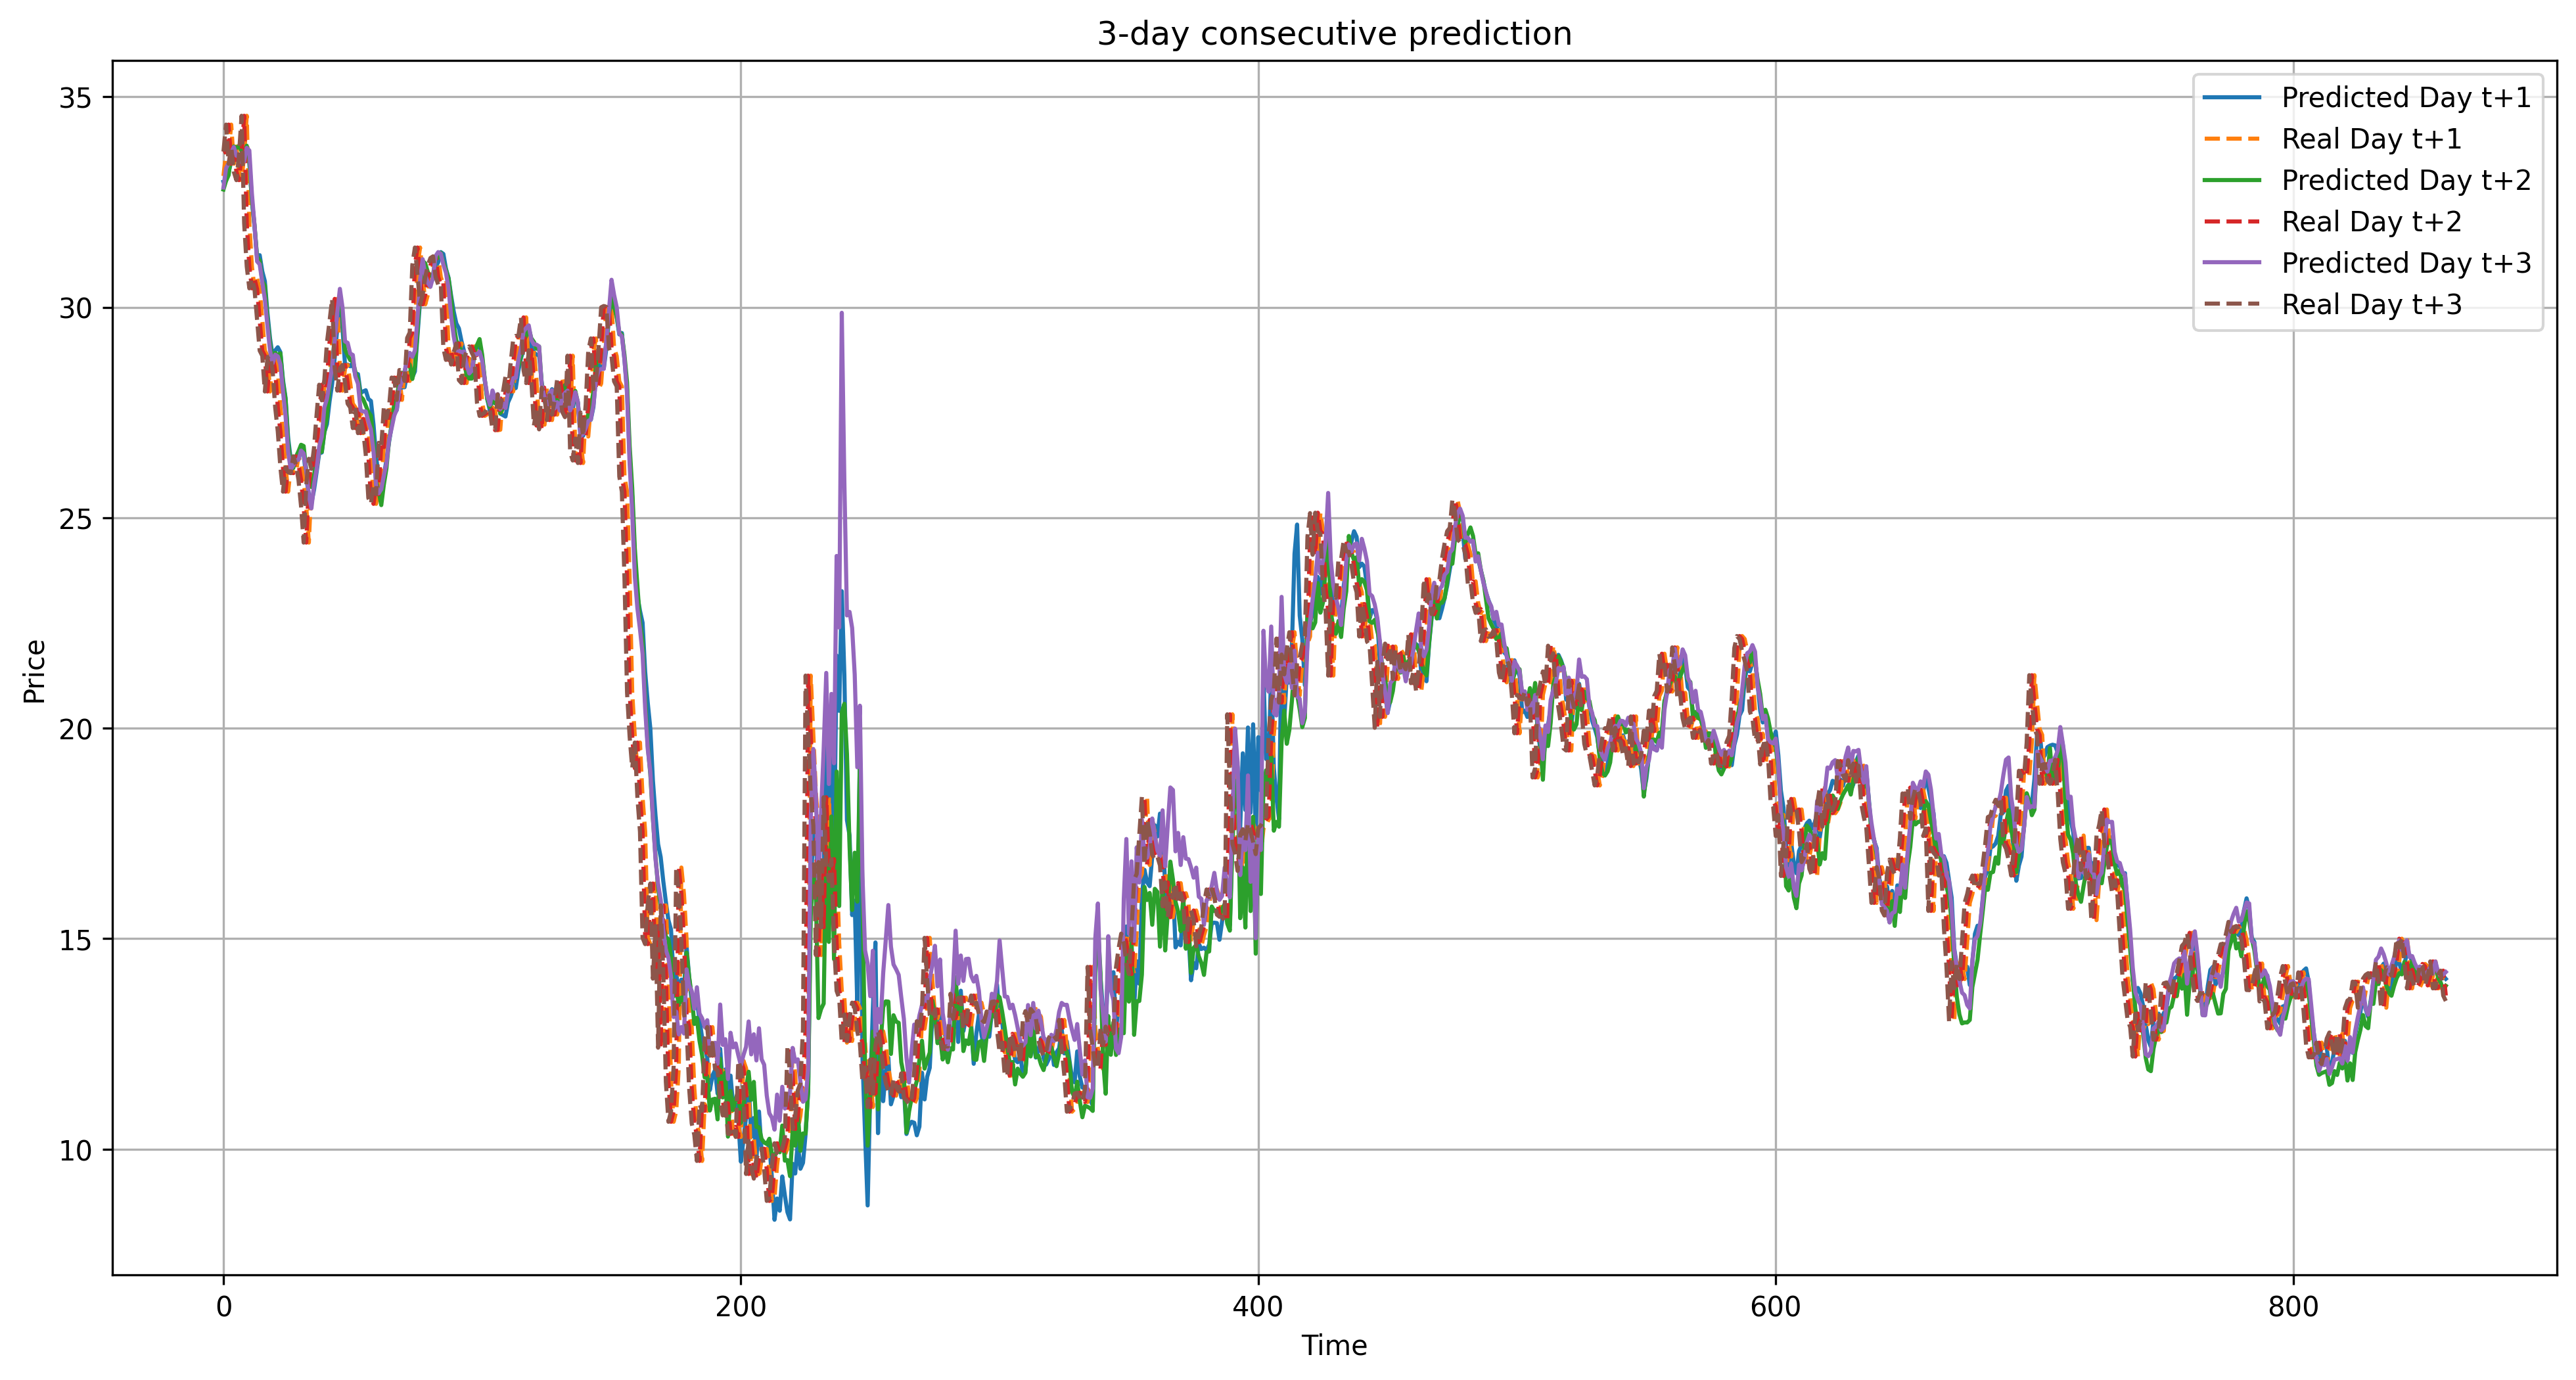

In [19]:
# Visualization
plt.figure(figsize=(16, 8), dpi=300)

for i in range(k):
    plt.plot(y_pred[:, i], label=f'Predicted Day t+{i+1}')
    plt.plot(y_test[:, i], linestyle='dashed', label=f'Real Day t+{i+1}')

plt.title(f'{k}-day consecutive prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()